*<small>Part B - Abdallah Yahia</small>*<br>
*<small>Q2. Supervised Text Classification</small>*

*<small>Task 1: Build the Supervised Text Classification Model: ***Linear SVM***</small>*

*<small>Description: We load the already-cleaned training and testing data, then build a pipeline that converts the review text into numbers using TF-IDF, and trains a Linear SVM model to predict whether a review is positive, negative, or neutral. At the end we make predictions on the test set and display a sample comparison of actual vs predicted labels.</small>*

*<small>Step 1: Import all required libraries</small>*

In [ ]:
# install pandas for loading and handling the dataset
%pip install pandas scikit-learn

In [3]:
# import pandas for loading and handling the dataset
import pandas as pd

# import TfidfVectorizer to convert text into numerical features
from sklearn.feature_extraction.text import TfidfVectorizer

# import LinearSVC as the classification model
from sklearn.svm import LinearSVC

# import Pipeline to chain TF-IDF and the model together
from sklearn.pipeline import Pipeline

print("All libraries imported successfully")

All libraries imported successfully


*<small>Step 2: Loading the training and testing datasets</small>*

In [4]:
# load the training and testing CSV files
train_df = pd.read_csv('../Data/train_set.csv')
test_df = pd.read_csv('../Data/test_set.csv')

# print shape and a preview of the training data
print(f"Training set: {train_df.shape[0]} rows, {train_df.shape[1]} columns")
print(f"Testing set: {test_df.shape[0]} rows, {test_df.shape[1]} columns")
print("\n--- Training Data Preview ---")
train_df.head()

Training set: 107768 rows, 2 columns
Testing set: 26945 rows, 2 columns

--- Training Data Preview ---


,Summary_clean,Sentiment
0,good product beautiful sound good packing chea...,positive
1,shown picture soft cute baby dress really liked,positive
2,great deal niece cloud nine quality also superb,positive
3,superb productthis second washing machine marq...,positive
4,dam masti like prodocts,positive


*<small>Step 3: Split features and labels for both datasets</small>*

In [5]:
# assign the text column as features (X) and the label column as targets (y)
X_train = train_df['Summary_clean']
y_train = train_df['Sentiment']

X_test = test_df['Summary_clean']
y_test = test_df['Sentiment']

# confirm the sizes of each split
print("--- Feature & Label Split ---")
print(f"X_train: {len(X_train)} samples | y_train: {len(y_train)} labels")
print(f"X_test: {len(X_test)} samples | y_test: {len(y_test)} labels")
print(f"\nLabel classes: {list(y_train.unique())}")

--- Feature & Label Split ---
X_train: 107768 samples | y_train: 107768 labels
X_test: 26945 samples | y_test: 26945 labels

Label classes: ['positive', 'negative', 'neutral']


*<small>Step 4: Build the pipeline (TF-IDF + LinearSVC)</small>*

In [6]:
# create a pipeline: Step 1 converts text to TF-IDF numbers, Step 2 trains the
# LinearSVC model
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC())
])

# confirm the pipeline was built successfully
print("--- Pipeline Steps ---")
for name, step in pipeline.steps:
    print(f" Step: {name} --> {type(step).__name__}")

--- Pipeline Steps ---
 Step: tfidf --> TfidfVectorizer
 Step: clf --> LinearSVC


*<small>Step 5: Train the model on the training data</small>*

In [7]:
print("Training the Linear SVM model...")

# fit the pipeline on the training data — this trains the model
pipeline.fit(X_train, y_train)

print("Model training complete")

Training the Linear SVM model...
Model training complete


*<small>Step 6: Predict on the test set and display a sample comparison</small>*

In [8]:
# use the trained pipeline to predict sentiments on the test set
y_pred = pipeline.predict(X_test)

# build a comparison table of the review text, actual label, and predicted label
results_df = pd.DataFrame({
    'Review': X_test.values,
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("--- Sample Predictions (first 10 rows) ---")
print(results_df.head(10).to_string(index=False))

--- Sample Predictions (first 10 rows) ---
                                                                                                                                                    Review   Actual Predicted
                                                                                                                                              good product positive  positive
                                                                                                                                           kettle lid good negative  negative
                                                                                                good product motorola feel freshness air purifies air mins positive  positive
                                                                          dont waste money fashionable onlyaccording price ok want something good dont buy negative  negative
                                                                                       

*<small>Task 2: Perform Model Evaluations</small>*

*<small>Description: Now that the model has made predictions, we evaluate how well it performed. We do this by comparing the predicted labels against the actual labels using four measures: Accuracy, Precision, Recall, and Macro F1-Score. We also display a Confusion Matrix to visually see where the model got things right or wrong.</small>*

*<small>Step 7: Import the evaluation libraries</small>*

In [ ]:
# installation
%pip install seaborn matplotlib

In [1]:
# import metrics to measure model performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# import seaborn and matplotlib to visualise the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluation libraries imported successfully")

Evaluation libraries imported successfully


*<small>Step 8: Calculate and print accuracy</small>*

In [ ]:
# calculate accuracy — the percentage of correct predictions out of all 
# predictions
accuracy = accuracy_score(y_test, y_pred)

print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy * 100:.2f}%")

--- Model Accuracy ---
Accuracy: 88.30%


*<small>Step 9: Print the full classification report (Precision, Recall, Macro F1-Score)</small>*

In [10]:
# generate a full report showing Precision, Recall, and F1-Score per class
report = classification_report(y_test, y_pred,
                                  target_names=['negative', 'neutral', 'positive'])

print("--- Classification Report ---")
print(report)

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.81      0.70      0.75      4949
     neutral       0.63      0.33      0.44      1540
    positive       0.91      0.97      0.94     20456

    accuracy                           0.88     26945
   macro avg       0.78      0.67      0.71     26945
weighted avg       0.87      0.88      0.87     26945



*<small>Step 10: Plot the confusion Matrix</small>*

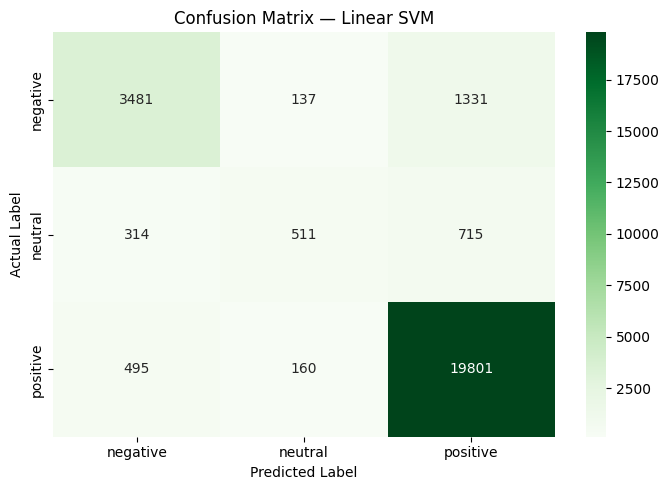

In [11]:
# build the confusion matrix from actual vs predicted labels
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, y_pred, labels=labels)

# plot the confusion matrix as a colour heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels, yticklabels=labels)

# add axis labels and a title to make the chart readable
plt.title('Confusion Matrix — Linear SVM')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

*<small>Task 4: Hyperp Parameter Tuning using GridSearchCV</small>*

*<small>Description: We use GridSearchCV, which tries every combination of hyperparameter values we give it, trains and tests the model for each one, and tells us which combination gave the best result. We then re-evaluate the tuned model and compare its performance to the original.<small>*

*<small>Step 11: Import GridSearchCV</small>*

In [ ]:
# import GridSearchCV to automatically search for the best hyperparameter 
# combination
from sklearn.model_selection import GridSearchCV

print("GridSearchCV imported successfully")

GridSearchCV imported successfully


*<small>Step 12: Define the hyperparamter grid to search through</small>*

In [13]:
# define the hyperparameter values to try — 'clf__' prefix targets the 
# LinearSVC step in the pipeline
param_grid = {
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__loss': ['hinge', 'squared_hinge'],
    'clf__max_iter': [1000, 3000, 5000]
}

# print a summary of the grid so we know what will be tested
total = 1
for key, values in param_grid.items():
    total *= len(values)
    print(f" {key}: {values}")
print(f"\nTotal combinations to test: {total} (x5 folds = {total*5} fits)")

 clf__C: [0.01, 0.1, 1, 10, 100]
 clf__loss: ['hinge', 'squared_hinge']
 clf__max_iter: [1000, 3000, 5000]

Total combinations to test: 30 (x5 folds = 150 fits)


*<small>Step 13: Run GridSearchCV to find the best hyperparameter combination</small>*

In [ ]:
print("Running GridSearchCV...")

# set up GridSearchCV with the pipeline, the param grid, 5-fold cross 
# validation, scored by macro F1
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

# fit GridSearchCV on the training data — it tries all combinations and 
# picks the best
grid_search.fit(X_train, y_train)

print("GridSearchCV complete")

Running GridSearchCV — this may take a moment...
GridSearchCV complete


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


*<small>Step 14: Print the best hyperparamteres found</small>*

In [15]:
# retrieve and print the best hyperparameter combination found by GridSearchCV
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_

print("--- Best Hyperparameters Found ---")
for param, value in best_params.items():
    print(f" {param}: {value}")
print(f"\nBest Cross-Validation Macro F1-Score: {best_cv_score:.4f}")

--- Best Hyperparameters Found ---
 clf__C: 1
 clf__loss: hinge
 clf__max_iter: 1000

Best Cross-Validation Macro F1-Score: 0.7171


*<small>Step 15: Evaluate the tuned model on the test set</small>*

In [16]:
# sse the best model found by GridSearchCV to predict on the test set
y_pred_tuned = grid_search.best_estimator_.predict(X_test)

# calculate accuracy for the tuned model
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

# print the full classification report for the tuned model
print("--- Tuned Model — Classification Report ---")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['negative', 'neutral', 'positive']))

--- Tuned Model — Classification Report ---
              precision    recall  f1-score   support

    negative       0.84      0.71      0.77      4949
     neutral       0.67      0.31      0.42      1540
    positive       0.90      0.97      0.94     20456

    accuracy                           0.89     26945
   macro avg       0.80      0.66      0.71     26945
weighted avg       0.88      0.89      0.88     26945



*<small>Step 16: Compare before and after tuning side by side</small>*

In [17]:
# gather the before and after metrics for a side-by-side comparison
from sklearn.metrics import f1_score, precision_score, recall_score

before = {
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'Macro F1': round(f1_score(y_test, y_pred, average='macro'), 4),
    'Macro Precision':round(precision_score(y_test, y_pred, average='macro'), 4),
    'Macro Recall': round(recall_score(y_test, y_pred, average='macro'), 4)
}

after = {
    'Accuracy': round(accuracy_score(y_test, y_pred_tuned), 4),
    'Macro F1': round(f1_score(y_test, y_pred_tuned, average='macro'), 4),
    'Macro Precision':round(precision_score(y_test, y_pred_tuned, average='macro'), 4),
    'Macro Recall': round(recall_score(y_test, y_pred_tuned, average='macro'), 4)
}

# print the comparison table
print("--- Before vs After Tuning ---")
print(f"{'Metric':<20} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 52)
for metric in before:
    diff = round(after[metric] - before[metric], 4)
    arrow = "▲" if diff > 0 else ("▼" if diff < 0 else "=")
    print(f"{metric:<20} {before[metric]:>10} {after[metric]:>10} {arrow} {diff:>6}")

--- Before vs After Tuning ---
Metric                   Before      After     Change
----------------------------------------------------
Accuracy                  0.883     0.8864 ▲ 0.0034
Macro F1                 0.7083     0.7084 ▲ 0.0001
Macro Precision          0.7834     0.8019 ▲ 0.0185
Macro Recall             0.6677      0.663 ▼ -0.0047
